# Epilepsy Detection with LSTMs — Training Notebook
*Generated: 2025-09-04 06:17:31*

This notebook trains a 2-layer LSTM to classify EEG segments as **epileptic (1)** vs **non-epileptic (0)**  
using the UCI *Epileptic Seizure Recognition* dataset (`/mnt/data/data.csv`).

**Pipeline**
1. Load & clean data  
2. Convert 5-class labels to binary (`1` → epileptic, else `0`)  
3. (Optional) Subsample every 4th row as described  
4. Normalize features (StandardScaler)  
5. Reshape to sequences of length 178 with 1 feature per timestep  
6. Train 2-layer LSTM (Adam + Binary Crossentropy), 50 epochs with early stopping  
7. Save model & scaler, and plot training curves

## 0. Setup

In [1]:
# If running locally, ensure you have these installed:
# !pip install numpy pandas scikit-learn matplotlib tensorflow==2.* joblib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

DATA_PATH = "/mnt/data/data.csv"   # Change if needed
MODEL_DIR = "/mnt/data/models"
MODEL_PATH = os.path.join(MODEL_DIR, "epilepsy_lstm.keras")
SCALER_PATH = os.path.join(MODEL_DIR, "scaler.joblib")

os.makedirs(MODEL_DIR, exist_ok=True)

print(tf.__version__)

2.21.0


## 1. Load data

In [8]:
# Load CSV (expects 178 feature columns + label column 'y' or last column)
# df = pd.read_csv('data.csv')
df = pd.read_csv("data.csv")

# Drop obvious unnamed index columns if present
for col in list(df.columns):
    if 'unnamed' in col.lower():
        df = df.drop(columns=[col])

print("Shape after load:", df.shape)
print("Columns:", df.columns[:10], "...")
df.head()

Shape after load: (11500, 179)
Columns: Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10'], dtype='str') ...


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


## 2. Prepare features and labels

In [9]:
# Try to locate label column
label_col = 'y' if 'y' in df.columns else df.columns[-1]

X = df.drop(columns=[label_col]).values
y_raw = df[label_col].values

# Convert to binary: 1 -> 1 (epileptic), {2,3,4,5} -> 0 (non-epileptic)
y = (y_raw == 1).astype(int)

print("Feature shape:", X.shape, "Label shape:", y.shape)
print("Class distribution (binary):", {0: int((y==0).sum()), 1: int((y==1).sum())})

Feature shape: (11500, 178) Label shape: (11500,)
Class distribution (binary): {0: 9200, 1: 2300}


## 3. Optional: take 1 in every 4 samples (subsampling)

In [10]:
TAKE_EVERY_4TH = True  # Set False to use full dataset

if TAKE_EVERY_4TH:
    X = X[::4]
    y = y[::4]
    print("After subsampling every 4th row ->", X.shape, y.shape)

After subsampling every 4th row -> (2875, 178) (2875,)


## 4. Train/Validation split

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (2300, 178) Val: (575, 178)


## 5. Normalize (StandardScaler)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)

SCALER_PATH = os.path.join(MODEL_DIR, "scaler2.joblib")

# Save scaler for use in the inference notebook
joblib.dump(scaler, SCALER_PATH)
print("Scaler saved to:", SCALER_PATH)



Scaler saved to: ./models\scaler2.joblib


## 6. Reshape to sequences for LSTM
We treat each sample as a sequence of length 178 with 1 feature per timestep.

In [19]:
def to_sequences(arr_2d):
    # arr_2d: (n_samples, 178) -> (n_samples, 178, 1)
    return arr_2d.reshape(arr_2d.shape[0], arr_2d.shape[1], 1)

X_train_seq = to_sequences(X_train_scaled)
X_val_seq   = to_sequences(X_val_scaled)

print("X_train_seq shape:", X_train_seq.shape)
print("X_val_seq shape:", X_val_seq.shape)

X_train_seq shape: (2300, 178, 1)
X_val_seq shape: (575, 178, 1)


In [22]:
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("Classes:", np.unique(y_train, return_counts=True))

y_train: (2300,)
y_val: (575,)
Classes: (array([0, 1]), array([1842,  458]))


In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 178, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 178, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,037 (343.90 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 58,692 (229.27 KB)

In [33]:
import numpy as np
import os

WEIGHTS_PATH = "./models/epilepsy_lstm2_weights.npz"

weights = model.get_weights()

np.savez(
    WEIGHTS_PATH,
    *weights
)

print("Saved", len(weights), "weight arrays to:", WEIGHTS_PATH)

Saved 8 weight arrays to: ./models/epilepsy_lstm2_weights.npz


## 7. Build 2-layer LSTM model

In [20]:
tf.keras.utils.set_random_seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\Dell\miniconda3\envs\clg-project\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 178, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 178, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train (50 epochs) with EarlyStopping & ModelCheckpoint

In [29]:

MODEL_DIR = "./models"
#MODEL_PATH = os.path.join(MODEL_DIR, "epilepsy_lstm2.keras")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    #ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)
]



In [30]:
history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print("Best model saved to:",MODEL_PATH )

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 372ms/step - accuracy: 0.9452 - loss: 0.1838 - val_accuracy: 0.9635 - val_loss: 0.1345
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 307ms/step - accuracy: 0.9322 - loss: 0.1671 - val_accuracy: 0.9600 - val_loss: 0.1250
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 314ms/step - accuracy: 0.9635 - loss: 0.1145 - val_accuracy: 0.9652 - val_loss: 0.0939
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 395ms/step - accuracy: 0.9661 - loss: 0.1195 - val_accuracy: 0.9670 - val_loss: 0.1114
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 301ms/step - accuracy: 0.9648 - loss: 0.1172 - val_accuracy: 0.9704 - val_loss: 0.0956
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step - accuracy: 0.9661 - loss: 0.1032 - val_accuracy: 0.9652 - val_loss: 0.1172
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 294ms/step - accuracy: 0.9474 - loss: 0.1338 - val_accuracy: 0.9617 - val_loss: 0.1132
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.9657 - loss: 0.0964 - val_accu

## 9. Plot training history

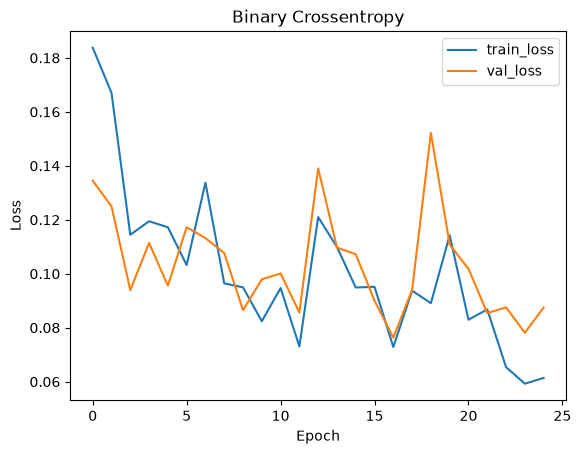

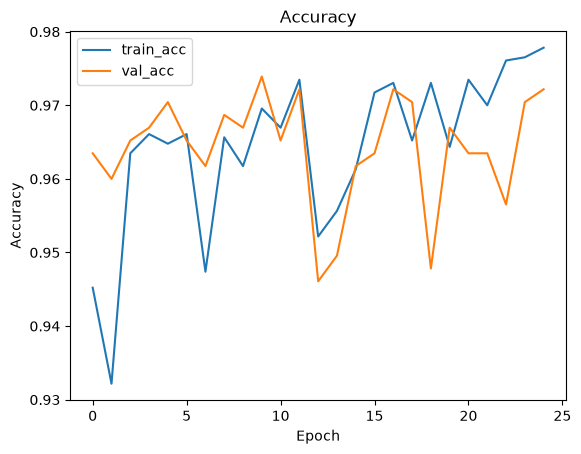

In [31]:
# Plot Loss
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Binary Crossentropy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 10. Quick validation metrics (AUC & report)

In [32]:
val_pred_prob = model.predict(X_val_seq).ravel()
val_pred_bin = (val_pred_prob >= 0.5).astype(int)

auc = roc_auc_score(y_val, val_pred_prob)
print("Validation ROC AUC:", round(auc, 4))

print("\nClassification report (val):")
print(classification_report(y_val, val_pred_bin, digits=4))

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
Validation ROC AUC: 0.9879

Classification report (val):
              precision    recall  f1-score   support

           0     0.9890    0.9761    0.9825       461
           1     0.9083    0.9561    0.9316       114

    accuracy                         0.9722       575
   macro avg     0.9487    0.9661    0.9571       575
weighted avg     0.9730    0.9722    0.9724       575

